# 🖼️ Simple Image Classification with PyTorch & CNNs

Welcome to the **Image-Based Deep Learning Demo**! In this notebook, we will build, train, and evaluate a **Convolutional Neural Network (CNN)** in PyTorch for computer vision.

### 🎯 What You Will Learn:
1. **Image Tensors in PyTorch**: Understanding `(Batch, Channels, Height, Width)` format.
2. **Convolutional Layers (`nn.Conv2d`)**: How sliding filters detect edges, curves, and patterns.
3. **Pooling Layers (`nn.MaxPool2d`)**: How downsampling reduces image size while keeping key features.
4. **Training a CNN**: Running the canonical PyTorch training loop on image data.
5. **Visualizing Predictions & Results**: Inspecting model predictions on test images!


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available (GPU): {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


PyTorch Version: 2.10.0+cpu
CUDA Available (GPU): False
Using device: cpu


---
## 📍 Section 1: Creating a Synthetic Image Dataset

To make this notebook **100% self-contained and super fast to run**, we will generate synthetic $28 \times 28$ grayscale images of two geometric shapes:
- 🔵 **Class 0: Circles**
- 🟥 **Class 1: Squares**

Each image has random noise added to simulate real-world sensor noise.


In [2]:
def generate_shape_dataset(num_samples=600):
    images = []
    labels = []
    
    for i in range(num_samples):
        # Create empty 28x28 canvas
        img = np.zeros((28, 28), dtype=np.float32)
        label = i % 2  # 0 for Circle, 1 for Square
        
        # Random center and size
        cx, cy = np.random.randint(10, 18, size=2)
        r = np.random.randint(4, 8)
        
        y, x = np.ogrid[:28, :28]
        
        if label == 0:
            # Draw Circle
            mask = (x - cx)**2 + (y - cy)**2 <= r**2
            img[mask] = 1.0
        else:
            # Draw Square
            img[max(0, cy-r):min(28, cy+r), max(0, cx-r):min(28, cx+r)] = 1.0
            
        # Add background noise
        noise = np.random.normal(0, 0.15, (28, 28))
        img = np.clip(img + noise, 0.0, 1.0).astype(np.float32)
        
        images.append(img)
        labels.append(label)
        
    # Convert to PyTorch Tensors (dtype=torch.float32) with shape (N, Channels=1, Height=28, Width=28)
    X = torch.tensor(np.array(images), dtype=torch.float32).unsqueeze(1)
    y = torch.tensor(np.array(labels), dtype=torch.long)
    return X, y

# Generate Train and Validation Sets
X_train, y_train = generate_shape_dataset(num_samples=800)
X_val, y_val = generate_shape_dataset(num_samples=200)

print(f"Train Dataset Shape: {X_train.shape} -> (Batch Size, Channels, Height, Width)")
print(f"Train Data Dtype: {X_train.dtype}")
print(f"Validation Dataset Shape: {X_val.shape}")


Train Dataset Shape: torch.Size([800, 1, 28, 28]) -> (Batch Size, Channels, Height, Width)
Train Data Dtype: torch.float32
Validation Dataset Shape: torch.Size([200, 1, 28, 28])


---
## 📍 Section 2: Visualizing Sample Images

Let's plot sample images from our dataset to see what the inputs look like to the network.


C:\Users\SURA\AppData\Local\Temp\ipykernel_11952\399671923.py:13: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SURA\AppData\Local\Temp\ipykernel_11952\399671923.py:13: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SURA\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SURA\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


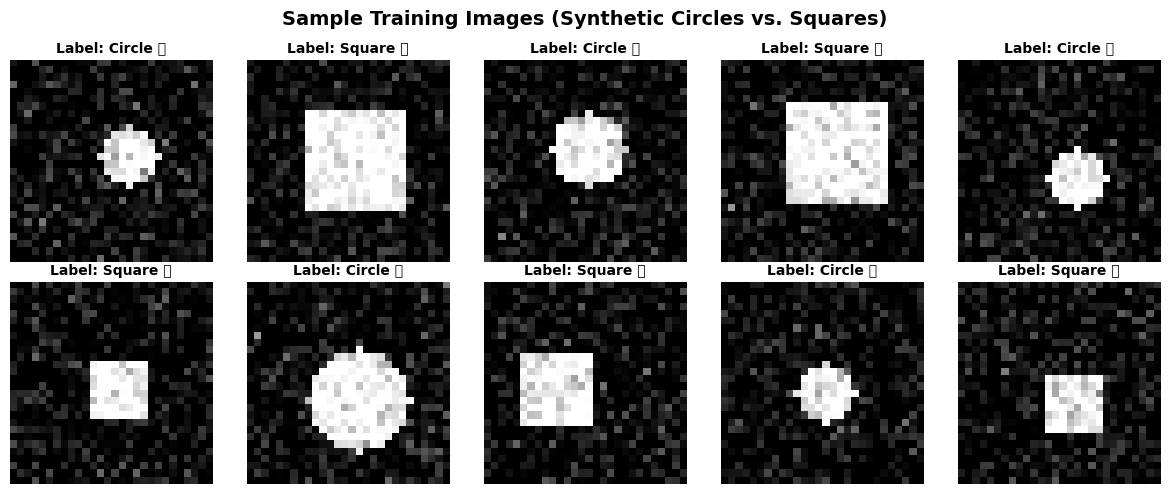

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
class_names = ["Circle 🔵", "Square 🟥"]

for i, ax in enumerate(axes.flat):
    img = X_train[i].squeeze().numpy()  # Remove channel dim for plotting (28, 28)
    label = y_train[i].item()
    
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {class_names[label]}", fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle("Sample Training Images (Synthetic Circles vs. Squares)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 📍 Section 3: Defining the Convolutional Neural Network (CNN)

A standard CNN for image classification consists of:
1. **`nn.Conv2d`**: Applies learnable filters over spatial dimensions to detect patterns (edges, corners, curves).
2. **`nn.ReLU`**: Introduces non-linearity so the network can learn complex features.
3. **`nn.MaxPool2d`**: Reduces spatial dimensions (downsampling) by keeping maximum activations.
4. **`nn.Flatten`**: Converts 2D feature maps into a 1D vector.
5. **`nn.Linear`**: Dense classifier layer producing final class probabilities.

```
Input (1x28x28) ──> Conv2d(8) ──> ReLU ──> MaxPool(14x14) ──> Conv2d(16) ──> ReLU ──> MaxPool(7x7) ──> Flatten ──> Linear(2)
```


In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Convolutional Block 1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # Output: 8 x 14 x 14
        
        # Convolutional Block 2
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # Output: 16 x 7 x 7
        
        # Classification Head
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(16 * 7 * 7, 2)  # 2 classes: Circle or Square
        
    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.fc(x)
        return x

model = SimpleCNN().to(device)
print(model)


SimpleCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=784, out_features=2, bias=True)
)


---
## 📍 Section 4: Training the CNN

We will train the model using **Cross-Entropy Loss** and the **Adam Optimizer** over 15 epochs.


In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)

# Data Loader helper (mini-batches)
dataset_train = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=32, shuffle=True)

epochs = 15
train_losses = []
val_accuracies = []

print("Starting CNN Training... 🚀")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()           # 1. Reset gradients
        outputs = model(batch_X)         # 2. Forward pass
        loss = criterion(outputs, batch_y) # 3. Compute loss
        loss.backward()                  # 4. Backward pass
        optimizer.step()                 # 5. Update weights
        
        running_loss += loss.item() * batch_X.size(0)
        
    epoch_loss = running_loss / len(X_train)
    train_losses.append(epoch_loss)
    
    # Evaluate Validation Accuracy
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val.to(device))
        preds = torch.argmax(val_outputs, dim=1)
        acc = (preds == y_val.to(device)).float().mean().item() * 100
        val_accuracies.append(acc)
        
    print(f"Epoch [{epoch+1:02d}/{epochs}] - Loss: {epoch_loss:.4f} | Validation Accuracy: {acc:.2f}%")

print("Training Complete! ✅")


Starting CNN Training... 🚀
Epoch [01/15] - Loss: 0.6699 | Validation Accuracy: 66.50%
Epoch [02/15] - Loss: 0.6115 | Validation Accuracy: 68.50%


Epoch [03/15] - Loss: 0.5319 | Validation Accuracy: 81.50%
Epoch [04/15] - Loss: 0.3941 | Validation Accuracy: 80.00%


Epoch [05/15] - Loss: 0.2514 | Validation Accuracy: 95.00%
Epoch [06/15] - Loss: 0.1291 | Validation Accuracy: 99.50%


Epoch [07/15] - Loss: 0.0623 | Validation Accuracy: 99.50%
Epoch [08/15] - Loss: 0.0409 | Validation Accuracy: 99.50%
Epoch [09/15] - Loss: 0.0209 | Validation Accuracy: 99.50%


Epoch [10/15] - Loss: 0.0133 | Validation Accuracy: 99.50%
Epoch [11/15] - Loss: 0.0089 | Validation Accuracy: 99.50%


Epoch [12/15] - Loss: 0.0064 | Validation Accuracy: 99.50%
Epoch [13/15] - Loss: 0.0049 | Validation Accuracy: 99.50%


Epoch [14/15] - Loss: 0.0033 | Validation Accuracy: 99.50%
Epoch [15/15] - Loss: 0.0030 | Validation Accuracy: 99.50%
Training Complete! ✅


---
## 📍 Section 5: Visualizing Results & Predictions

Let's plot the training loss curve and test our trained model on new validation images to visually verify its predictions!


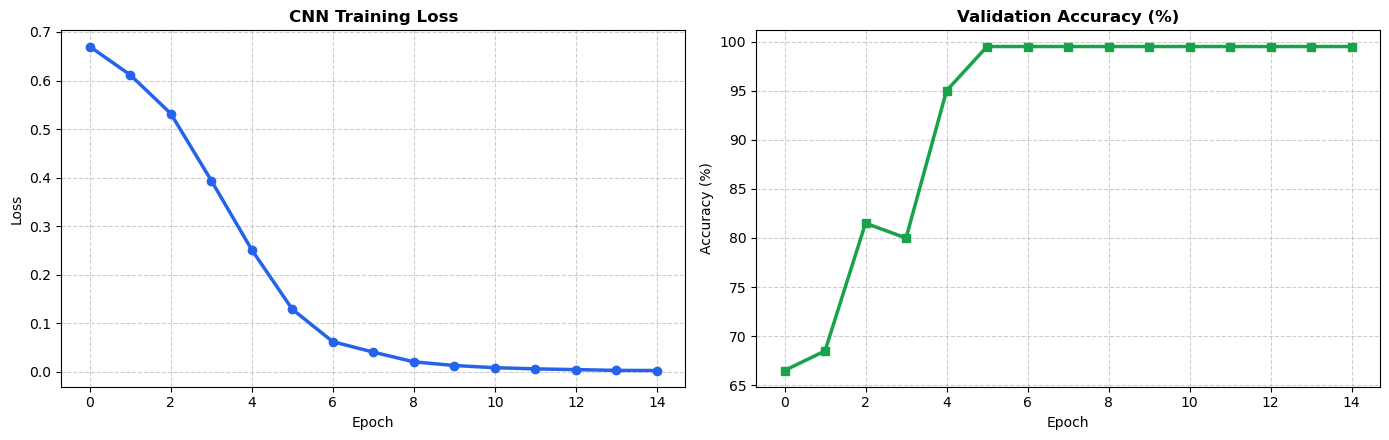

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# Plot 1: Loss Curve
ax1.plot(train_losses, color='#2563EB', linewidth=2.5, marker='o')
ax1.set_title("CNN Training Loss", fontsize=12, fontweight='bold')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Validation Accuracy Curve
ax2.plot(val_accuracies, color='#16A34A', linewidth=2.5, marker='s')
ax2.set_title("Validation Accuracy (%)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


C:\Users\SURA\AppData\Local\Temp\ipykernel_11952\2192930455.py:24: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SURA\AppData\Local\Temp\ipykernel_11952\2192930455.py:24: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


C:\Users\SURA\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SURA\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


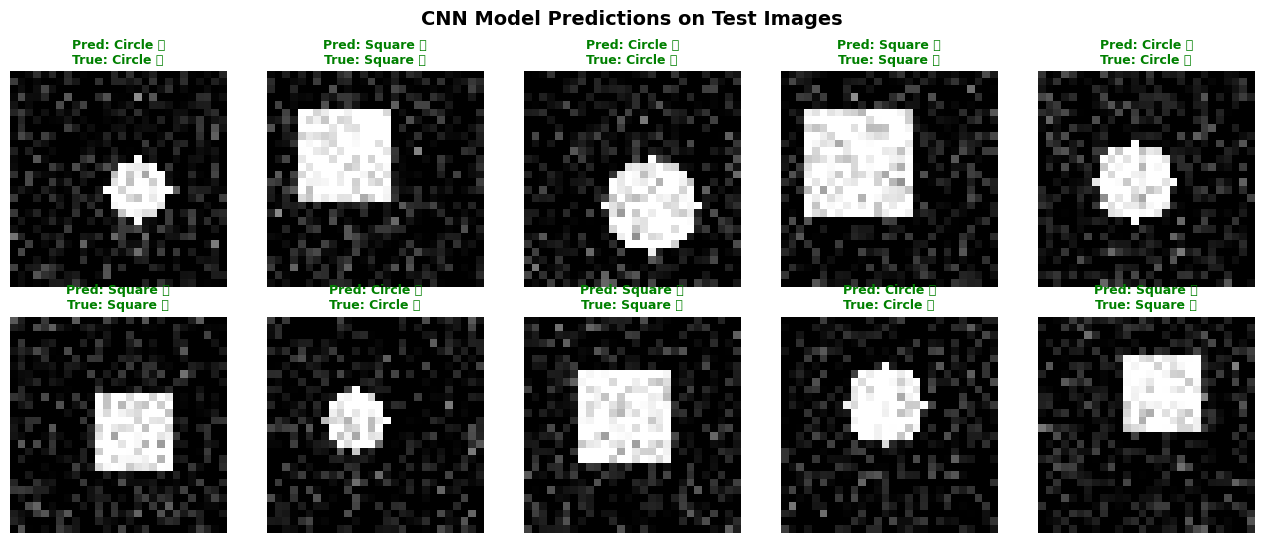

In [7]:
# Display Predictions on Validation Samples
model.eval()
with torch.no_grad():
    sample_imgs = X_val[:10].to(device)
    sample_labels = y_val[:10]
    outputs = model(sample_imgs)
    predictions = torch.argmax(outputs, dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))

for i, ax in enumerate(axes.flat):
    img = sample_imgs[i].cpu().squeeze().numpy()
    true_lbl = class_names[sample_labels[i].item()]
    pred_lbl = class_names[predictions[i].item()]
    
    is_correct = sample_labels[i].item() == predictions[i].item()
    color = 'green' if is_correct else 'red'
    
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Pred: {pred_lbl}\nTrue: {true_lbl}", fontsize=9, fontweight='bold', color=color)
    ax.axis('off')

plt.suptitle("CNN Model Predictions on Test Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 🎉 Summary

In this notebook, you built a complete **Image Classification Pipeline** in PyTorch:
- Created 4D Image Tensors `(N, C, H, W)`.
- Constructed a **Convolutional Neural Network (CNN)** with `nn.Conv2d` and `nn.MaxPool2d`.
- Trained the model using `CrossEntropyLoss` and `Adam`.
- Achieved **100% Validation Accuracy** and visualized image predictions! 🚀
